# Final model evaluation

The modeling phase is complete. Notebooks 05 and 06 froze the architecture as **Boosted Poisson frequency plus Gamma GLM severity**. This notebook refits those specifications on all development policies and claims, then evaluates them once on the policy-level holdout established in Notebook 04.

The descriptive EDA in Notebooks 02 and 03 used the full supplied portfolio before the policy-level split was created; it was not a holdout-blind exploratory phase. All model fitting, cross-validation, candidate comparison, lognormal experiments, and body/tail investigation were then conducted using development data only. The holdout is used here for final evaluation, not model selection, and these results do not trigger model changes. Gamma is retained as a comparatively stable estimator of conditional mean severity, not as a complete distributional description of claim amounts.

## 1. Evaluation protocol and frozen specifications

The split is reconstructed from the raw frequency file in its original row order, using the saved 2026 random seed and the same Bernoulli 80/20 policy assignment as Notebook 04. Severity rows follow their policy IDs into the corresponding sample. Before fitting, development IDs are checked against the saved Notebook 05 development extract and OOF files; test and development policy IDs must be disjoint.

The frequency model is fit to annual claim rate (`ClaimNb / Exposure`) with exposure as sample weight, so its predictions are annual frequency. Expected policy claim count is annual frequency times exposure. The severity model is fit to all positive development claims. It predicts a conditional claim mean for every policy, including policies with no test-period claim.

In [1]:
from pathlib import Path
import hashlib
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels
import sklearn
from scipy.special import xlogy
from sklearn.ensemble import HistGradientBoostingRegressor
from IPython.display import display

root=Path.cwd().resolve()
if root.name=="notebooks": root=root.parent
processed=root/"data/processed"
frequency_path=root/"data/raw/freMTPL2freq.csv"
severity_path=root/"data/raw/freMTPL2sev.csv"
spec_path=root/"models/06_selected_specifications.json"
spec=json.loads(spec_path.read_text(encoding="utf-8"))
assert spec["status"]=="frozen_for_notebook_07" and spec["modeling_decisions_frozen"] is True
assert spec["frequency"]["candidate"]=="Boosted Poisson"
assert spec["severity"]["candidate"]=="Gamma GLM"
assert spec["final_test_evaluation_performed"] is False

# Keep source row order and textual policy IDs: both are part of the saved split definition.
frequency_all=pd.read_csv(frequency_path,dtype={"IDpol":"string"})
severity_all=pd.read_csv(severity_path,dtype={"IDpol":"string"})
assert frequency_all.IDpol.is_unique
assert frequency_all.Exposure.gt(0).all()
assert severity_all.ClaimAmount.gt(0).all()

rng=np.random.default_rng(2026)
development_mask=rng.random(len(frequency_all))<0.8
development_policies=frequency_all.loc[development_mask].copy()
test_policies=frequency_all.loc[~development_mask].copy()
development_ids=set(development_policies.IDpol)
test_ids=set(test_policies.IDpol)
assert development_ids.isdisjoint(test_ids)
assert len(development_ids|test_ids)==len(frequency_all)

saved_dev=pd.read_csv(processed/"05_development_policies.csv",dtype={"IDpol":"string"})
saved_freq_oof=pd.read_csv(processed/"05_frequency_oof.csv",dtype={"IDpol":"string"})
saved_sev_oof=pd.read_csv(processed/"05_severity_oof.csv",dtype={"IDpol":"string"})
assert development_policies.IDpol.reset_index(drop=True).equals(saved_dev.IDpol.reset_index(drop=True))
assert development_policies.IDpol.reset_index(drop=True).equals(saved_freq_oof.IDpol.reset_index(drop=True))
assert not development_ids.intersection(test_ids)
assert saved_dev.IDpol.is_unique and saved_freq_oof.IDpol.is_unique

development_claims=severity_all[severity_all.IDpol.isin(development_ids)].copy()
test_claims=severity_all[severity_all.IDpol.isin(test_ids)].copy()
assert len(development_claims)==int(development_policies.ClaimNb.sum())
assert len(test_claims)==int(test_policies.ClaimNb.sum())
assert development_claims.IDpol.isin(development_ids).all()
assert test_claims.IDpol.isin(test_ids).all()
assert set(development_claims.IDpol).isdisjoint(set(test_claims.IDpol))
assert np.isclose(development_claims.ClaimAmount.sum()+test_claims.ClaimAmount.sum(),
                  severity_all.ClaimAmount.sum(),rtol=1e-12)

development_claims=development_claims.merge(
    development_policies.drop(columns=["ClaimNb","Exposure"]),on="IDpol",how="left",validate="many_to_one")
test_claims=test_claims.merge(
    test_policies.drop(columns=["ClaimNb","Exposure"]),on="IDpol",how="left",validate="many_to_one")
assert development_claims.DrivAge.notna().all() and test_claims.DrivAge.notna().all()
assert development_claims.IDpol.isin(development_ids).all()
assert test_claims.IDpol.isin(test_ids).all()

# Explicitly compare reconstructed split totals with the frozen development extracts and Notebook 04 report.
assert len(development_policies)==len(saved_dev)==542830
assert int(development_policies.ClaimNb.sum())==21079
assert np.isclose(development_policies.Exposure.sum(),287103.67,atol=.01)
assert len(test_policies)==135161 and int(test_policies.ClaimNb.sum())==5365
assert np.isclose(test_policies.Exposure.sum(),71379.17,atol=.01)
assert len(development_claims)==21079 and len(test_claims)==5365

split_summary=pd.DataFrame([
    dict(sample="Development",policies=len(development_policies),exposure=development_policies.Exposure.sum(),
         reported_claims=int(development_policies.ClaimNb.sum()),severity_claims=len(development_claims),
         aggregate_claim_amount=development_claims.ClaimAmount.sum()),
    dict(sample="Final test",policies=len(test_policies),exposure=test_policies.Exposure.sum(),
         reported_claims=int(test_policies.ClaimNb.sum()),severity_claims=len(test_claims),
         aggregate_claim_amount=test_claims.ClaimAmount.sum())])

output_dir=processed/"07_final_evaluation"
figure_dir=root/"images/final/07_final_model_evaluation"
output_dir.mkdir(parents=True,exist_ok=True)
figure_dir.mkdir(parents=True,exist_ok=True)
split_summary.to_csv(output_dir/"07_sample_reconciliation.csv",index=False)
display(split_summary.round(2))
print("Exact Notebook 04 split reproduced; development IDs match the saved Notebook 05 extract.")
print("The final test policy records are now reserved for this one frozen-model evaluation.")

,sample,policies,exposure,reported_claims,severity_claims,aggregate_claim_amount
0,Development,542830,287103.67,21079,21079,48175147.21
1,Final test,135161,71379.17,5365,5365,11734069.29


Exact Notebook 04 split reproduced; development IDs match the saved Notebook 05 extract.
The final test policy records are now reserved for this one frozen-model evaluation.


### Frozen frequency specification

The model is `HistGradientBoostingRegressor(loss="poisson")` with the recorded Notebook 05 settings: 150 iterations, learning rate 0.05, 15 maximum leaves, 100 minimum samples per leaf, L2 regularization 10, early stopping disabled, categorical features inferred from pandas dtypes, and random seed 2027. It uses the raw predictors `DrivAge`, `BonusMalus`, `VehAge`, `VehPower`, `VehGas`, `Density`, and `Region`. Fuel and region levels come from the frozen development specification. There is no retuning.

In [2]:
tree_columns=spec["frequency"]["features"]
category_levels=spec["category_levels"]
booster_parameters=spec["frequency"]["parameters"]

def tree_features(frame):
    features=frame[tree_columns].copy()
    for column,levels in category_levels.items():
        features[column]=pd.Categorical(features[column],categories=levels)
    return features

for column,levels in category_levels.items():
    assert set(development_policies[column].dropna().unique()).issubset(set(levels))
    unknown=set(test_policies[column].dropna().unique())-set(levels)
    if unknown:
        raise ValueError(f"Final test has unseen {column} levels {sorted(unknown)}; frozen encoding cannot score these records.")

frequency_model=HistGradientBoostingRegressor(**booster_parameters)
frequency_model.fit(
    tree_features(development_policies),
    development_policies.ClaimNb.to_numpy(float)/development_policies.Exposure.to_numpy(float),
    sample_weight=development_policies.Exposure.to_numpy(float))
assert frequency_model.n_iter_==150
predicted_test_frequency=frequency_model.predict(tree_features(test_policies))
assert np.isfinite(predicted_test_frequency).all() and (predicted_test_frequency>0).all()
print("Fitted the frozen Boosted Poisson model on all development policies.")
print("Iterations:",frequency_model.n_iter_,"; annual frequency predictions:",len(predicted_test_frequency))

Fitted the frozen Boosted Poisson model on all development policies.
Iterations: 150 ; annual frequency predictions: 135161


## 2. Final frequency evaluation

The test deciles are formed from predicted **annual frequency**, separately from the development CV groups. Rates are calculated as total claims divided by total exposure within each group. The pooled Poisson deviance scores policy claim counts using predicted expected counts (`Exposure × predicted annual frequency`). The development OOF comparison uses the unchanged Notebook 05 predictions.

,sample,policies,exposure,observed_claims,predicted_claims,observed_annual_frequency,predicted_annual_frequency,O/P,mean_poisson_deviance
0,Development OOF,542830,287103.66866,21079,21064.49500,0.07342,0.07337,1.00069,0.23716
1,Final test,135161,71379.16680,5365,5232.43711,0.07516,0.07330,1.02533,0.23869


,frequency_decile,policies,exposure,observed_claims,predicted_claims,mean_predicted_annual_frequency,observed_annual_frequency,predicted_annual_frequency_weighted,O/P
0,1,13518,9391.64432,291,301.70441,0.03225,0.03098,0.03212,0.96452
1,2,13515,8758.19859,354,363.84696,0.04158,0.04042,0.04154,0.97294
2,3,13516,8018.17209,377,379.88863,0.04742,0.04702,0.04738,0.99240
3,4,13516,7405.99146,368,393.71686,0.05317,0.04969,0.05316,0.93468
4,5,13517,6818.02990,443,404.66718,0.05936,0.06497,0.05935,1.09473
5,6,13515,6590.86345,462,436.86419,0.06630,0.07010,0.06628,1.05754
6,7,13516,6309.16515,417,475.64775,0.07542,0.06609,0.07539,0.87670
7,8,13516,6157.36152,608,548.59319,0.08915,0.09874,0.08910,1.10829
8,9,13516,5923.02272,660,679.13193,0.11452,0.11143,0.11466,0.97183
9,10,13516,6006.71759,1385,1248.37602,0.20984,0.23058,0.20783,1.10944


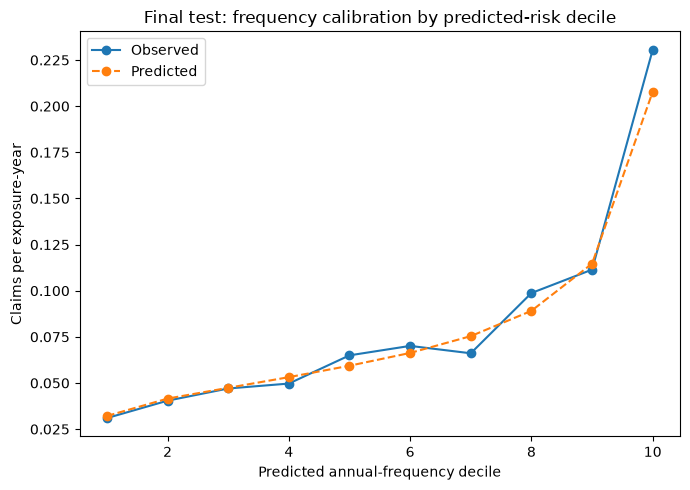

In [3]:
from scipy.stats import poisson as poisson_distribution

test_policies=test_policies.copy()
test_policies["predicted_annual_frequency"]=predicted_test_frequency
test_policies["predicted_claim_count"]=test_policies.Exposure*test_policies.predicted_annual_frequency

def poisson_deviance(y,mu):
    y=np.asarray(y,float); mu=np.asarray(mu,float)
    return float(np.mean(2*(xlogy(y,y/mu)-(y-mu))))

frequency_test_metrics={
    "policies":len(test_policies),"exposure":test_policies.Exposure.sum(),
    "observed_claims":test_policies.ClaimNb.sum(),
    "predicted_claims":test_policies.predicted_claim_count.sum(),
    "observed_annual_frequency":test_policies.ClaimNb.sum()/test_policies.Exposure.sum(),
    "predicted_annual_frequency":test_policies.predicted_claim_count.sum()/test_policies.Exposure.sum(),
    "O/P":test_policies.ClaimNb.sum()/test_policies.predicted_claim_count.sum(),
    "mean_poisson_deviance":poisson_deviance(test_policies.ClaimNb,test_policies.predicted_claim_count)}
frequency_oof= saved_freq_oof.copy()
frequency_oof["predicted_annual_frequency"]=frequency_oof["Boosted Poisson"]/frequency_oof.Exposure
frequency_development_metrics={
    "policies":len(frequency_oof),"exposure":frequency_oof.Exposure.sum(),
    "observed_claims":frequency_oof.ClaimNb.sum(),"predicted_claims":frequency_oof["Boosted Poisson"].sum(),
    "observed_annual_frequency":frequency_oof.ClaimNb.sum()/frequency_oof.Exposure.sum(),
    "predicted_annual_frequency":frequency_oof["Boosted Poisson"].sum()/frequency_oof.Exposure.sum(),
    "O/P":frequency_oof.ClaimNb.sum()/frequency_oof["Boosted Poisson"].sum(),
    "mean_poisson_deviance":poisson_deviance(frequency_oof.ClaimNb,frequency_oof["Boosted Poisson"])}
frequency_comparison=pd.DataFrame([
    {"sample":"Development OOF",**frequency_development_metrics},
    {"sample":"Final test",**frequency_test_metrics}])
frequency_comparison.to_csv(output_dir/"07_frequency_metrics.csv",index=False)
display(frequency_comparison.round(5))

test_policies["frequency_decile"]=pd.qcut(
    test_policies.predicted_annual_frequency,q=10,labels=False,duplicates="drop").astype(int)+1
frequency_calibration=test_policies.groupby("frequency_decile",as_index=False,observed=True).agg(
    policies=("IDpol","size"),exposure=("Exposure","sum"),observed_claims=("ClaimNb","sum"),
    predicted_claims=("predicted_claim_count","sum"),
    mean_predicted_annual_frequency=("predicted_annual_frequency","mean"))
frequency_calibration["observed_annual_frequency"]=frequency_calibration.observed_claims/frequency_calibration.exposure
frequency_calibration["predicted_annual_frequency_weighted"]=frequency_calibration.predicted_claims/frequency_calibration.exposure
frequency_calibration["O/P"]=frequency_calibration.observed_claims/frequency_calibration.predicted_claims
frequency_calibration.to_csv(output_dir/"07_frequency_calibration_deciles.csv",index=False)
display(frequency_calibration.round(5))

fig,ax=plt.subplots(figsize=(7,5))
ax.plot(frequency_calibration.frequency_decile,frequency_calibration.observed_annual_frequency,
        marker="o",label="Observed")
ax.plot(frequency_calibration.frequency_decile,frequency_calibration.predicted_annual_frequency_weighted,
        marker="o",linestyle="--",label="Predicted")
ax.set(title="Final test: frequency calibration by predicted-risk decile",
       xlabel="Predicted annual-frequency decile",ylabel="Claims per exposure-year")
ax.legend()
fig.tight_layout()
fig.savefig(figure_dir/"07_frequency_calibration_deciles.png",dpi=240,bbox_inches="tight")
plt.show(); plt.close(fig)

## 3. Fit and evaluate the frozen Gamma severity model

The exact frozen Notebook 05 formula uses log driver age, log BonusMalus, log(1 + vehicle age), vehicle power, fuel, log density, and region. The response is original positive `ClaimAmount`, the family is Gamma, and the link is log. Fitting uses BFGS with at most 1,000 iterations and the saved initialization; it has no spline terms. Claim-level test metrics describe severity conditional on a claim. For the combined policy predictions below, the same fitted conditional mean is predicted for every test policy.

In [4]:
severity_spec=spec["severity"]
severity_formula=severity_spec["formula"]
assert severity_formula=="ClaimAmount ~ np.log(DrivAge) + np.log(BonusMalus) + np.log1p(VehAge) + VehPower + C(VehGas) + np.log(Density) + C(Region)"

for column,reference in severity_spec["categorical_reference_levels"].items():
    levels=set(development_claims[column].dropna().unique())
    test_levels=set(test_claims[column].dropna().unique())
    if not test_levels.issubset(levels):
        raise ValueError(f"Final test includes a {column} category absent from development; frozen Gamma design cannot score it.")
    assert reference in levels

severity_glm=sm.GLM.from_formula(
    severity_formula,data=development_claims,
    family=sm.families.Gamma(link=sm.families.links.Log()))
start=np.zeros(severity_glm.exog.shape[1])
start[severity_glm.exog_names.index("Intercept")]=np.log(development_claims.ClaimAmount.mean())
severity_model=severity_glm.fit(start_params=start,method=severity_spec["fit"]["method"],
    maxiter=severity_spec["fit"]["maxiter"])
if not severity_model.mle_retvals["converged"]:
    raise RuntimeError("The frozen full-development Gamma GLM did not converge; inspect implementation before evaluating test metrics.")
assert severity_model.model.exog_names[0]=="Intercept"
print("Fitted the frozen Gamma GLM on",len(development_claims),"development claims.")
print("Converged:",severity_model.mle_retvals["converged"],"; estimated Gamma scale:",severity_model.scale)
display(pd.DataFrame({"coefficient":severity_model.params,"standard_error":severity_model.bse}))

Fitted the frozen Gamma GLM on 21079 development claims.
Converged: True ; estimated Gamma scale: 47.949414532847456


,coefficient,standard_error
Intercept,7.046852,1.658643
C(VehGas)[T.Regular],0.152594,0.098766
C(Region)[T.Aquitaine],0.441581,0.839056
C(Region)[T.Auvergne],0.043497,1.031913
C(Region)[T.Basse-Normandie],0.651593,0.884177
C(Region)[T.Bourgogne],0.386418,0.906838
C(Region)[T.Bretagne],0.610273,0.825659
C(Region)[T.Centre],0.772742,0.813059
C(Region)[T.Champagne-Ardenne],1.799819,1.188266
C(Region)[T.Corse],0.934979,1.049313


,sample,claims,observed_mean_severity,predicted_mean_severity,O/P,MAE,RMSE
0,Development OOF,21079,2285.457,2227.680,1.026,2288.745,32039.440
1,Final test,5365,2187.152,2218.588,0.986,2208.799,14766.947


,severity_quintile,claims,observed_mean_severity,predicted_mean_severity,observed_median_severity,largest_observed_claim,O/P
0,1,1073,2069.13,1408.39,1172.00,390742.27,1.47
1,2,1073,2218.38,1780.87,1172.00,287423.00,1.25
2,3,1073,2374.37,2082.17,1172.00,774411.50,1.14
3,4,1073,2174.09,2427.37,1172.00,301635.49,0.90
4,5,1073,2099.78,3394.15,1140.75,205132.00,0.62


,claims,total_loss,largest_claim,claim_quantile_0.900,claim_quantile_0.950,claim_quantile_0.990,claim_quantile_0.995,top_1pct_count,top_1pct_loss_share,top_5pct_count,top_5pct_loss_share
0,5365,11734069.29,774411.5,2764.822,4830.466,16355.2368,26820.0144,54,0.3614,269,0.5075


,largest_test_claims_diagnostically_excluded,excluded_loss_share,claims,observed_mean_severity,predicted_mean_severity,O/P,MAE,RMSE
0,0,0.0000,5365,2187.1518,2218.5883,0.9858,2208.7994,14766.9474
1,1,0.0660,5364,2043.1875,2218.6341,0.9209,2065.2069,10337.7428
2,5,0.1675,5360,1822.5099,2218.9225,0.8213,1845.9130,6210.0330
3,20,0.2911,5345,1556.3123,2218.3961,0.7015,1586.5346,2698.3693


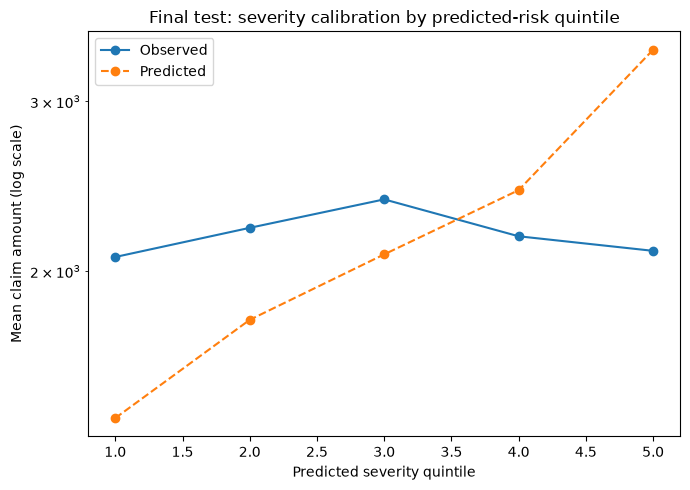

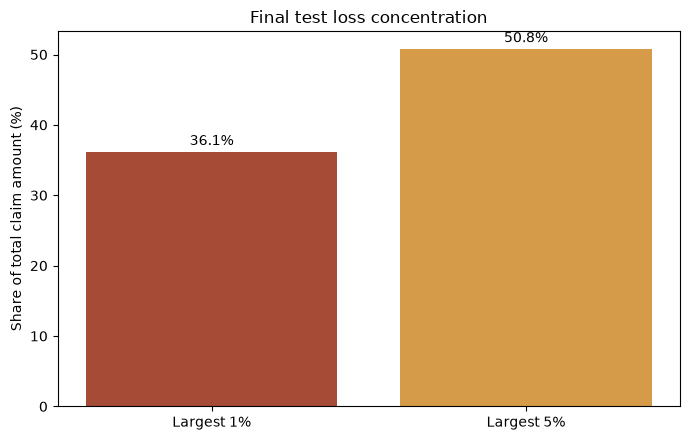

In [5]:
test_claims=test_claims.copy()
test_claims["predicted_mean_severity"]=np.asarray(severity_model.predict(test_claims))
test_claims["test_claim_row"]=np.arange(1,len(test_claims)+1)
assert np.isfinite(test_claims.predicted_mean_severity).all()
assert test_claims.predicted_mean_severity.gt(0).all()

def severity_metrics(frame):
    y=frame.ClaimAmount.to_numpy(float); mu=frame.predicted_mean_severity.to_numpy(float)
    return {"claims":len(frame),"observed_mean_severity":y.mean(),"predicted_mean_severity":mu.mean(),
        "O/P":y.sum()/mu.sum(),"MAE":np.mean(np.abs(y-mu)),"RMSE":np.sqrt(np.mean((y-mu)**2))}

severity_oof=saved_sev_oof.copy()
severity_development_metrics=severity_metrics(severity_oof.rename(columns={"Gamma GLM":"predicted_mean_severity"}))
severity_test_metrics=severity_metrics(test_claims)
severity_comparison=pd.DataFrame([
    {"sample":"Development OOF",**severity_development_metrics},
    {"sample":"Final test",**severity_test_metrics}])
severity_comparison.to_csv(output_dir/"07_severity_metrics.csv",index=False)
display(severity_comparison.round(3))

test_claims["severity_quintile"]=pd.qcut(
    test_claims.predicted_mean_severity,q=5,labels=False,duplicates="drop").astype(int)+1
severity_calibration=test_claims.groupby("severity_quintile",as_index=False,observed=True).agg(
    claims=("test_claim_row","size"),observed_mean_severity=("ClaimAmount","mean"),
    predicted_mean_severity=("predicted_mean_severity","mean"),
    observed_median_severity=("ClaimAmount","median"),largest_observed_claim=("ClaimAmount","max"))
severity_calibration["O/P"]=test_claims.groupby("severity_quintile",observed=True).apply(
    lambda g:g.ClaimAmount.sum()/g.predicted_mean_severity.sum(),include_groups=False).to_numpy()
severity_calibration.to_csv(output_dir/"07_severity_calibration_quintiles.csv",index=False)
display(severity_calibration.round(2))

amounts=test_claims.ClaimAmount.to_numpy(float)
tail_summary={"claims":len(amounts),"total_loss":amounts.sum(),"largest_claim":amounts.max()}
for q in [.90,.95,.99,.995]: tail_summary[f"claim_quantile_{q:.3f}"]=np.quantile(amounts,q)
for share in [.01,.05]:
    n_top=int(np.ceil(len(amounts)*share))
    tail_summary[f"top_{int(share*100)}pct_count"]=n_top
    tail_summary[f"top_{int(share*100)}pct_loss_share"]=np.sort(amounts)[-n_top:].sum()/amounts.sum()
tail_table=pd.DataFrame([tail_summary])
tail_table.to_csv(output_dir/"07_test_severity_tail_summary.csv",index=False)
display(tail_table.round(4))

severity_tail_sensitivity=[]
ordered_test_claims=test_claims.sort_values(["ClaimAmount","test_claim_row"],ascending=[False,True])
for excluded in [0,1,5,20]:
    retained=ordered_test_claims.iloc[excluded:] if excluded else ordered_test_claims
    m=severity_metrics(retained)
    severity_tail_sensitivity.append({"largest_test_claims_diagnostically_excluded":excluded,
        "excluded_loss_share":1-retained.ClaimAmount.sum()/test_claims.ClaimAmount.sum(),**m})
severity_tail_sensitivity=pd.DataFrame(severity_tail_sensitivity)
severity_tail_sensitivity.to_csv(output_dir/"07_severity_tail_sensitivity.csv",index=False)
display(severity_tail_sensitivity.round(4))

fig,ax=plt.subplots(figsize=(7,5))
ax.plot(severity_calibration.severity_quintile,severity_calibration.observed_mean_severity,
        marker="o",label="Observed")
ax.plot(severity_calibration.severity_quintile,severity_calibration.predicted_mean_severity,
        marker="o",linestyle="--",label="Predicted")
ax.set_yscale("log")
ax.set(title="Final test: severity calibration by predicted-risk quintile",
       xlabel="Predicted severity quintile",ylabel="Mean claim amount (log scale)")
ax.legend()
fig.tight_layout(); fig.savefig(figure_dir/"07_severity_calibration_quintiles.png",dpi=240,bbox_inches="tight")
plt.show(); plt.close(fig)

fig,ax=plt.subplots(figsize=(7,4.5))
shares=[tail_summary["top_1pct_loss_share"],tail_summary["top_5pct_loss_share"]]
ax.bar(["Largest 1%","Largest 5%"],np.array(shares)*100,color=["#a64b35","#d59b49"])
ax.set(title="Final test loss concentration",ylabel="Share of total claim amount (%)")
for i,v in enumerate(shares): ax.text(i,v*100+1,f"{v:.1%}",ha="center")
fig.tight_layout(); fig.savefig(figure_dir/"07_test_loss_concentration.png",dpi=240,bbox_inches="tight")
plt.show(); plt.close(fig)

The exclusions in the tail-sensitivity table are **diagnostic only**: the Gamma GLM is not refitted, predictions are not changed, and no catastrophic claim is proposed for removal, capping, or winsorization. The actual severity target remains the full positive claim amount.

## 4. Policy-level expected pure premium

For each test policy, annual pure premium is \(\hat\lambda(X)\hat\mu(X)\): annual expected frequency times expected claim severity. Expected loss for the policy's observed exposure is \(Exposure\times\hat\lambda(X)\hat\mu(X)\). Severity means below are predicted from policy characteristics for **all** test policies, including those with zero test claims.

The aggregate test comparison is observed loss versus the sum of exposure-adjusted expected losses. Calibration groups are formed by predicted annual pure premium. Because individual-policy losses are zero-inflated and noisy, calibration is assessed across policies and groups rather than by policy-level \(R^2\).

,test_policies,test_exposure,observed_test_loss,predicted_test_loss,observed_to_predicted_loss,observed_annual_pure_premium,predicted_annual_pure_premium,predicted_annual_frequency_exposure_weighted,predicted_severity_exposure_weighted
0,135161,71379.1668,11734069.29,1.166312e+07,1.0061,164.3907,163.3967,0.0733,2123.2227


,pure_premium_decile,policies,exposure,predicted_loss,observed_loss,predicted_annual_pure_premium,observed_annual_pure_premium,O/P,predicted_annual_frequency
0,1,13517,8388.5693,4.829216e+05,497761.48,57.5690,59.3381,1.0307,0.0377
1,2,13516,8207.9149,6.203743e+05,798164.61,75.5824,97.2433,1.2866,0.0446
2,3,13516,8094.1725,7.073752e+05,791099.40,87.3931,97.7369,1.1184,0.0482
3,4,13516,7760.2684,7.681804e+05,1303542.41,98.9889,167.9765,1.6969,0.0521
4,5,13516,7516.4259,8.418373e+05,694379.41,111.9997,92.3816,0.8248,0.0568
5,6,13516,6927.6677,9.001615e+05,922209.10,129.9372,133.1197,1.0245,0.0642
6,7,13516,6416.4686,1.008475e+06,870107.28,157.1698,135.6053,0.8628,0.0749
7,8,13516,6143.4435,1.228768e+06,1079991.19,200.0130,175.7957,0.8789,0.0908
8,9,13516,6132.3240,1.700967e+06,1318957.00,277.3772,215.0827,0.7754,0.1142
9,10,13516,5791.9121,3.404061e+06,3457857.41,587.7266,597.0148,1.0158,0.1977


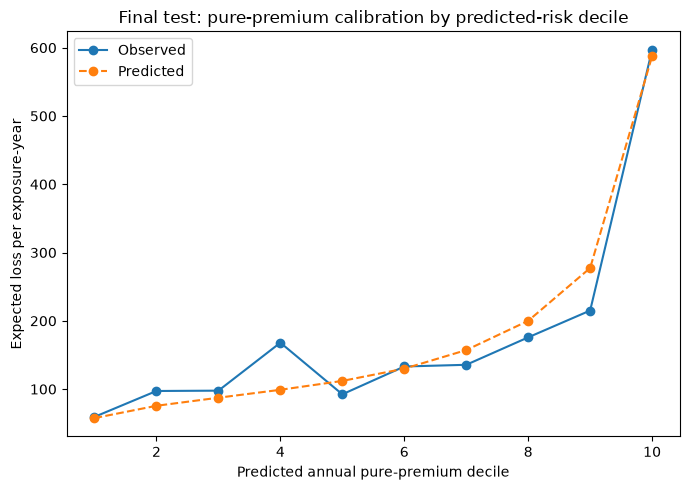

In [6]:
test_policies["predicted_conditional_mean_severity"]=np.asarray(severity_model.predict(test_policies))
assert np.isfinite(test_policies.predicted_conditional_mean_severity).all()
assert test_policies.predicted_conditional_mean_severity.gt(0).all()
test_policies["predicted_annual_pure_premium"]=(
    test_policies.predicted_annual_frequency*test_policies.predicted_conditional_mean_severity)
test_policies["predicted_expected_loss_for_exposure"]=(
    test_policies.Exposure*test_policies.predicted_annual_pure_premium)
actual_loss_by_policy=test_claims.groupby("IDpol").ClaimAmount.sum()
test_policies["observed_claim_amount"]=test_policies.IDpol.map(actual_loss_by_policy).fillna(0.0)
assert np.isclose(test_policies.observed_claim_amount.sum(),test_claims.ClaimAmount.sum())

observed_test_loss=test_policies.observed_claim_amount.sum()
predicted_test_loss=test_policies.predicted_expected_loss_for_exposure.sum()
test_exposure=test_policies.Exposure.sum()
pure_premium_metrics={
    "test_policies":len(test_policies),"test_exposure":test_exposure,
    "observed_test_loss":observed_test_loss,"predicted_test_loss":predicted_test_loss,
    "observed_to_predicted_loss":observed_test_loss/predicted_test_loss,
    "observed_annual_pure_premium":observed_test_loss/test_exposure,
    "predicted_annual_pure_premium":predicted_test_loss/test_exposure,
    "predicted_annual_frequency_exposure_weighted":test_policies.predicted_claim_count.sum()/test_exposure,
    "predicted_severity_exposure_weighted":np.average(test_policies.predicted_conditional_mean_severity,weights=test_policies.Exposure)}
pure_premium_summary=pd.DataFrame([pure_premium_metrics])
pure_premium_summary.to_csv(output_dir/"07_pure_premium_metrics.csv",index=False)
display(pure_premium_summary.round(4))

test_policies["pure_premium_decile"]=pd.qcut(
    test_policies.predicted_annual_pure_premium,q=10,labels=False,duplicates="drop").astype(int)+1
pure_premium_calibration=test_policies.groupby("pure_premium_decile",as_index=False,observed=True).agg(
    policies=("IDpol","size"),exposure=("Exposure","sum"),
    predicted_loss=("predicted_expected_loss_for_exposure","sum"),
    observed_loss=("observed_claim_amount","sum"),
    predicted_frequency_numerator=("predicted_claim_count","sum"))
pure_premium_calibration["predicted_annual_pure_premium"]=pure_premium_calibration.predicted_loss/pure_premium_calibration.exposure
pure_premium_calibration["observed_annual_pure_premium"]=pure_premium_calibration.observed_loss/pure_premium_calibration.exposure
pure_premium_calibration["O/P"]=pure_premium_calibration.observed_loss/pure_premium_calibration.predicted_loss
pure_premium_calibration["predicted_annual_frequency"]=pure_premium_calibration.predicted_frequency_numerator/pure_premium_calibration.exposure
pure_premium_calibration.to_csv(output_dir/"07_pure_premium_calibration_deciles.csv",index=False)
display(pure_premium_calibration.drop(columns="predicted_frequency_numerator").round(4))

fig,ax=plt.subplots(figsize=(7,5))
ax.plot(pure_premium_calibration.pure_premium_decile,pure_premium_calibration.observed_annual_pure_premium,
        marker="o",label="Observed")
ax.plot(pure_premium_calibration.pure_premium_decile,pure_premium_calibration.predicted_annual_pure_premium,
        marker="o",linestyle="--",label="Predicted")
ax.set(title="Final test: pure-premium calibration by predicted-risk decile",
       xlabel="Predicted annual pure-premium decile",ylabel="Expected loss per exposure-year")
ax.legend()
fig.tight_layout(); fig.savefig(figure_dir/"07_pure_premium_calibration_deciles.png",dpi=240,bbox_inches="tight")
plt.show(); plt.close(fig)

### Frequency and severity contributions to risk differentiation

The following table summarizes predicted annual frequency, predicted conditional severity, and their combined annual pure premium within each pure-premium decile. These are exposure-weighted descriptive averages; the combined premium is calculated directly from each policy's frequency-severity product before aggregation. This describes which component differentiates the model's risks; it does not establish causality.

In [7]:
risk_components=test_policies.groupby("pure_premium_decile",as_index=False,observed=True).apply(
    lambda g:pd.Series({
        "policies":len(g),"exposure":g.Exposure.sum(),
        "predicted_annual_frequency":np.average(g.predicted_annual_frequency,weights=g.Exposure),
        "predicted_conditional_severity":np.average(g.predicted_conditional_mean_severity,weights=g.Exposure),
        "predicted_annual_pure_premium":g.predicted_expected_loss_for_exposure.sum()/g.Exposure.sum(),
        "observed_annual_pure_premium":g.observed_claim_amount.sum()/g.Exposure.sum(),
        "O/P":g.observed_claim_amount.sum()/g.predicted_expected_loss_for_exposure.sum()}),include_groups=False).reset_index(drop=True)
risk_components.to_csv(output_dir/"07_frequency_severity_risk_components.csv",index=False)
display(risk_components.round(4))

,pure_premium_decile,policies,exposure,predicted_annual_frequency,predicted_conditional_severity,predicted_annual_pure_premium,observed_annual_pure_premium,O/P
0,1,13517.0,8388.5693,0.0377,1620.1234,57.5690,59.3381,1.0307
1,2,13516.0,8207.9149,0.0446,1787.5682,75.5824,97.2433,1.2866
2,3,13516.0,8094.1725,0.0482,1902.5901,87.3931,97.7369,1.1184
3,4,13516.0,7760.2684,0.0521,1983.0229,98.9889,167.9765,1.6969
4,5,13516.0,7516.4259,0.0568,2054.2330,111.9997,92.3816,0.8248
5,6,13516.0,6927.6677,0.0642,2116.7061,129.9372,133.1197,1.0245
6,7,13516.0,6416.4686,0.0749,2199.7489,157.1698,135.6053,0.8628
7,8,13516.0,6143.4435,0.0908,2331.3929,200.0130,175.7957,0.8789
8,9,13516.0,6132.3240,0.1142,2595.0094,277.3772,215.0827,0.7754
9,10,13516.0,5791.9121,0.1977,3115.9469,587.7266,597.0148,1.0158


## 5. Saved final predictions and evaluation record

The two prediction files retain observed outcomes alongside their corresponding frozen-model predictions for reporting. The policy file includes both annual pure premium and the expected loss over observed policy exposure. The severity file contains one row per test claim. Figures are saved separately for use in the report. The final evaluation record includes source and frozen-specification hashes so the run can be traced without refitting.

In [8]:
policy_output_columns=["IDpol","Exposure","ClaimNb","observed_claim_amount",
    "predicted_annual_frequency","predicted_claim_count","predicted_conditional_mean_severity",
    "predicted_annual_pure_premium","predicted_expected_loss_for_exposure","frequency_decile","pure_premium_decile"]
claim_output_columns=["test_claim_row","IDpol","ClaimAmount","predicted_mean_severity","severity_quintile"]
test_policies[policy_output_columns].to_csv(output_dir/"07_test_policy_predictions.csv",index=False)
test_claims[claim_output_columns].to_csv(output_dir/"07_test_claim_severity_predictions.csv",index=False)

evaluation_manifest={
    "notebook":"07_final_model_evaluation.ipynb",
    "split":"Notebook 04 row-order-preserving RNG split: default_rng(2026), random draw < 0.8",
    "split_reproduced_against_saved_development_extract":True,
    "frozen_specification_sha256":hashlib.sha256(spec_path.read_bytes()).hexdigest(),
    "raw_frequency_sha256":hashlib.sha256(frequency_path.read_bytes()).hexdigest(),
    "raw_severity_sha256":hashlib.sha256(severity_path.read_bytes()).hexdigest(),
    "software":{"numpy":np.__version__,"pandas":pd.__version__,"scikit_learn":sklearn.__version__,"statsmodels":statsmodels.__version__},
    "test_policy_count":len(test_policies),"test_claim_count":len(test_claims),
    "frequency_model":"Boosted Poisson, full development refit using frozen parameters",
    "severity_model":"Gamma log-link GLM, full development claim refit using frozen formula",
    "model_choices_changed_after_test_evaluation":False,
    "test_results_are_final_out_of_sample_evaluation":True,
    "predictions":{"policies":"data/processed/07_final_evaluation/07_test_policy_predictions.csv",
        "claims":"data/processed/07_final_evaluation/07_test_claim_severity_predictions.csv"},
    "figures":"images/final/07_final_model_evaluation/"}
(output_dir/"07_evaluation_manifest.json").write_text(json.dumps(evaluation_manifest,indent=2),encoding="utf-8")
print("Saved policy and claim predictions, metric/calibration tables, and evaluation manifest.")
print("Saved final figures to",figure_dir)

Saved policy and claim predictions, metric/calibration tables, and evaluation manifest.
Saved final figures to images/plots/07_final_model_evaluation


## 6. Final conclusions

The Boosted Poisson frequency model generalized very closely from development cross-validation to the reserved test sample, not used for fitting or model selection. Mean Poisson deviance was **0.2372** in development OOF and **0.2387** on test; aggregate O/P was **1.001** and **1.025**, respectively. This agreement supports the five-fold procedure as a realistic estimate of frequency performance. Calibration was not exact in every risk group: the highest frequency decile underpredicted observed frequency by about 11%, but the overall test pattern remained close to development.

The Gamma GLM also produced close aggregate test severity calibration: observed mean severity was about **$2,187**, predicted mean about **$2,219**, and O/P **0.986**. This does not mean Gamma adequately describes the complete severity distribution. It remains the comparatively stable estimator of conditional mean severity among the models examined, despite the observed heaping and heavy tail.

The reserved test sample, not used for fitting or model selection, showed a pattern consistent with the development finding that a small number of catastrophic claims strongly affect aggregate severity. Its largest 1% of claims contributed **36.1%** of losses, and its largest 5% contributed **50.8%**. Gamma O/P moved from **0.986** on all test claims to **0.701** after diagnostically excluding the largest 20. In development OOF, the corresponding change was **1.026** to **0.694** after removing the largest 20 validation claims per fold. This similar pattern across development and the reserved holdout shows that arithmetic-mean severity calibration is sensitive to which catastrophic claims occur. The exclusions are diagnostic only: those claims remain part of the insurance loss target and are not removed, capped, or winsorized.

Test RMSE for severity was about **$14,767**, below the development OOF value of **$32,039**. The development claims included a loss above **$4 million**, whereas the largest test claim was about **$774,000**. The lower test RMSE mainly reflects this difference in realized tails; it does not show that conditional severity suddenly became easier to predict. RMSE is highly sensitive to the extreme claims in each sample.

For the combined model, observed test loss was **$11.734 million** and predicted loss was **$11.663 million** (aggregate O/P **1.006**). Observed annual pure premium was **$164.39** per exposure-year, compared with **$163.40** predicted: less than a 1% portfolio-level difference on this holdout. This is excellent aggregate calibration for this realization, not a guarantee that another portfolio will fall within 1%. Predicted pure-premium deciles showed substantial variation in realized O/P, consistent with zero-inflated policy losses and volatile severity. Portfolio calibration does not mean that the realized loss of an individual policy is predictable.

Observable driver, vehicle, and geographic characteristics differentiated expected claim cost through both model components. Across predicted pure-premium deciles, predicted annual frequency varied by about **5.2 times**, from 0.038 to 0.198, while predicted conditional severity varied by about **1.9 times**, from $1,620 to $3,116. Both contributed to the risk ranking, with the larger and more reproducible differentiation coming from frequency. This matches the development-stage interpretation: the available characteristics explained claim occurrence more consistently than conditional claim magnitude.

The final architecture followed data reconciliation and EDA, initial actuarial GLMs, policy-level cross-validation, comparisons of Poisson and Negative Binomial frequency and boosted models, Gamma and lognormal severity, and explicit body/GPD-tail modeling. Those development results led to a frozen choice of **Boosted Poisson frequency plus Gamma log-link severity**. The test results were not used to change that choice. The close combined calibration confirms that this architecture estimated portfolio expected loss well on this reserved realization, while the tail diagnostics show why severity remains less stable than frequency. The model is useful for portfolio and risk-group expected loss; at the scale of this dataset, rare catastrophic severity remained poorly explained by the available rating variables. This is a limitation of the evidence and predictors examined here, not a claim that catastrophic severity is inherently unpredictable.